In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

In [5]:
from pathlib import Path

data_path = Path("paysim.csv")

df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")

Dataset shape: (6362620, 11)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.6400,C1231006815,170136.0000,160296.3600,M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,1864.2800,C1666544295,21249.0000,19384.7200,M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,21182.0000,0.0000,1,0
4,1,PAYMENT,11668.1400,C2048537720,41554.0000,29885.8600,M1230701703,0.0000,0.0000,0,0


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,6362620.0000,NaN,NaN,NaN,243.3972,142.3320,1.0000,156.0000,239.0000,335.0000,743.0000
type,6362620,5,CASH_OUT,2237500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,6362620.0000,NaN,NaN,NaN,179861.9035,603858.2315,0.0000,13389.5700,74871.9400,208721.4775,92445516.6400
nameOrig,6362620,6353307,C1902386530,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,6362620.0000,NaN,NaN,NaN,833883.1041,2888242.6730,0.0000,0.0000,14208.0000,107315.1750,59585040.3700
newbalanceOrig,6362620.0000,NaN,NaN,NaN,855113.6686,2924048.5030,0.0000,0.0000,0.0000,144258.4100,49585040.3700
nameDest,6362620,2722362,C1286084959,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,6362620.0000,NaN,NaN,NaN,1100701.6665,3399180.1130,0.0000,0.0000,132705.6650,943036.7075,356015889.3500
newbalanceDest,6362620.0000,NaN,NaN,NaN,1224996.3982,3674128.9421,0.0000,0.0000,214661.4400,1111909.2500,356179278.9200
isFraud,6362620.0000,NaN,NaN,NaN,0.0013,0.0359,0.0000,0.0000,0.0000,0.0000,1.0000


In [9]:
missing = df.isna().sum()

print("Missing values:")
print(missing)

print("\nTotal missing values:", missing.sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Total missing values: 0

Duplicate rows: 0


In [10]:
print("Target distribution:")
print(df["isFraud"].value_counts())

print("\nTarget percentage:")
print(
    df["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
)

Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Target percentage:
isFraud
0   99.8709
1    0.1291
Name: proportion, dtype: float64


In [11]:
print("Transaction types:")
print(df["type"].value_counts())

print("\nTransaction type percentages:")
print(
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
)

print("\nUnique values:")
print(df.nunique())

print("\nConstant columns:")
print(df.nunique()[df.nunique() == 1])

Transaction types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Transaction type percentages:
type
CASH_OUT   35.1663
PAYMENT    33.8146
CASH_IN    21.9923
TRANSFER    8.3756
DEBIT       0.6512
Name: proportion, dtype: float64

Unique values:
step                  743
type                    5
amount            5316900
nameOrig          6353307
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
oldbalanceDest    3614697
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64

Constant columns:
Series([], dtype: int64)


In [12]:
print("isFlaggedFraud distribution:")
print(df["isFlaggedFraud"].value_counts())

print("\nFraud rate by isFlaggedFraud:")
print(
    df.groupby("isFlaggedFraud")["isFraud"]
      .agg(["count", "sum", "mean"])
)

print("\nCross-tabulation:")
print(
    pd.crosstab(
        df["isFlaggedFraud"],
        df["isFraud"],
        margins=True
    )
)

isFlaggedFraud distribution:
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

Fraud rate by isFlaggedFraud:
                  count   sum   mean
isFlaggedFraud                      
0               6362604  8197 0.0013
1                    16    16 1.0000

Cross-tabulation:
isFraud               0     1      All
isFlaggedFraud                        
0               6354407  8197  6362604
1                     0    16       16
All             6354407  8213  6362620


In [13]:
flagged = df[df["isFlaggedFraud"] == 1]

print(flagged)

         step      type        amount     nameOrig  oldbalanceOrg  \
2736446   212  TRANSFER  4953893.0800   C728984460   4953893.0800   
3247297   250  TRANSFER  1343002.0800  C1100582606   1343002.0800   
3760288   279  TRANSFER   536624.4100  C1035541766    536624.4100   
5563713   387  TRANSFER  4892193.0900   C908544136   4892193.0900   
5996407   425  TRANSFER 10000000.0000   C689608084  19585040.3700   
5996409   425  TRANSFER  9585040.3700   C452586515  19585040.3700   
6168499   554  TRANSFER  3576297.1000   C193696150   3576297.1000   
6205439   586  TRANSFER   353874.2200  C1684585475    353874.2200   
6266413   617  TRANSFER  2542664.2700   C786455622   2542664.2700   
6281482   646  TRANSFER 10000000.0000    C19004745  10399045.0800   
6281484   646  TRANSFER   399045.0800   C724693370  10399045.0800   
6296014   671  TRANSFER  3441041.4600   C917414431   3441041.4600   
6351225   702  TRANSFER  3171085.5900  C1892216157   3171085.5900   
6362460   730  TRANSFER 10000000.0

In [14]:
print("\nTransaction types:")
print(flagged["type"].value_counts())

print("\nFraud amounts:")
print(flagged["amount"].describe())

print("\nSender balance patterns:")
print(
    flagged[
        ["amount", "oldbalanceOrg", "newbalanceOrig"]
    ]
)


Transaction types:
type
TRANSFER    16
Name: count, dtype: int64

Fraud amounts:
count         16.0000
mean     4861597.7306
std      3572499.1023
min       353874.2200
25%      2242748.7225
50%      4234245.0950
75%      7883451.3800
max     10000000.0000
Name: amount, dtype: float64

Sender balance patterns:
               amount  oldbalanceOrg  newbalanceOrig
2736446  4953893.0800   4953893.0800    4953893.0800
3247297  1343002.0800   1343002.0800    1343002.0800
3760288   536624.4100    536624.4100     536624.4100
5563713  4892193.0900   4892193.0900    4892193.0900
5996407 10000000.0000  19585040.3700   19585040.3700
5996409  9585040.3700  19585040.3700   19585040.3700
6168499  3576297.1000   3576297.1000    3576297.1000
6205439   353874.2200    353874.2200     353874.2200
6266413  2542664.2700   2542664.2700    2542664.2700
6281482 10000000.0000  10399045.0800   10399045.0800
6281484   399045.0800  10399045.0800   10399045.0800
6296014  3441041.4600   3441041.4600    3441041.460

In [15]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
      .agg(
          transactions="count",
          fraud_cases="sum",
          fraud_rate="mean"
      )
      .sort_values("fraud_rate", ascending=False)
)

fraud_by_type["fraud_rate_pct"] = fraud_by_type["fraud_rate"] * 100

print(fraud_by_type)

          transactions  fraud_cases  fraud_rate  fraud_rate_pct
type                                                           
TRANSFER        532909         4097      0.0077          0.7688
CASH_OUT       2237500         4116      0.0018          0.1840
CASH_IN        1399284            0      0.0000          0.0000
DEBIT            41432            0      0.0000          0.0000
PAYMENT        2151495            0      0.0000          0.0000


In [16]:
print("\nFraud cases by transaction type:")
print(
    df.loc[df["isFraud"] == 1, "type"]
      .value_counts()
)


Fraud cases by transaction type:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


In [17]:
print("Overall amount statistics:")
print(df["amount"].describe())

print("\nLegitimate amount statistics:")
print(
    df.loc[df["isFraud"] == 0, "amount"]
      .describe()
)

print("\nFraud amount statistics:")
print(
    df.loc[df["isFraud"] == 1, "amount"]
      .describe()
)

Overall amount statistics:
count    6362620.0000
mean      179861.9035
std       603858.2315
min            0.0000
25%        13389.5700
50%        74871.9400
75%       208721.4775
max     92445516.6400
Name: amount, dtype: float64

Legitimate amount statistics:
count    6354407.0000
mean      178197.0417
std       596236.9813
min            0.0100
25%        13368.3950
50%        74684.7200
75%       208364.7600
max     92445516.6400
Name: amount, dtype: float64

Fraud amount statistics:
count       8213.0000
mean     1467967.2991
std      2404252.9472
min            0.0000
25%       127091.3300
50%       441423.4400
75%      1517771.4800
max     10000000.0000
Name: amount, dtype: float64


In [18]:
print("\nFraud amount by transaction type:")
print(
    df.loc[df["isFraud"] == 1]
      .groupby("type")["amount"]
      .describe()
)


Fraud amount by transaction type:
             count         mean          std     min         25%         50%  \
type                                                                           
CASH_OUT 4116.0000 1455102.5860 2393841.7858  0.0000 125464.4500 435516.9050   
TRANSFER 4097.0000 1480891.6729 2414890.3787 63.8000 128417.9600 445705.7600   

                  75%           max  
type                                 
CASH_OUT 1500761.0300 10000000.0000  
TRANSFER 1534985.0700 10000000.0000  


In [19]:
df["orig_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]

df["dest_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]
)

print("Original balance discrepancy:")
print(df["orig_balance_change"].describe())

print("\nDestination balance discrepancy:")
print(df["dest_balance_change"].describe())

Original balance discrepancy:
count     6362620.0000
mean      -201092.4681
std        606650.4601
min     -92445516.6400
25%       -249641.0875
50%        -68677.2550
75%         -2954.2300
max             0.0100
Name: orig_balance_change, dtype: float64

Destination balance discrepancy:
count     6362620.0000
mean       -55567.1719
std        441528.7688
min     -13191233.9800
25%        -29353.0450
50%         -3500.4900
75%             0.0000
max      75885725.6300
Name: dest_balance_change, dtype: float64


In [20]:
print("\nOriginal balance discrepancy by target:")
print(
    df.groupby("isFraud")["orig_balance_change"]
      .describe()
)

print("\nDestination balance discrepancy by target:")
print(
    df.groupby("isFraud")["dest_balance_change"]
      .describe()
)


Original balance discrepancy by target:


               count         mean         std            min          25%  \
isFraud                                                                     
0       6354407.0000 -201338.5581 606928.8908 -92445516.6400 -249953.4300   
1          8213.0000  -10692.3253 265146.1311 -10000000.0000       0.0000   

                50%        75%    max  
isFraud                                
0       -69049.3100 -3034.3050 0.0100  
1            0.0000     0.0000 0.0000  

Destination balance discrepancy by target:
               count         mean          std            min          25%  \
isFraud                                                                      
0       6354407.0000  -54692.2317  436002.6325 -13191233.9800  -29259.8050   
1          8213.0000 -732509.3011 1867747.9906 -10000000.0000 -442722.0100   

               50%    75%           max  
isFraud                                  
0       -3500.6800 0.0000 75885725.6300  
1       -2231.4600 0.0000  8875516.2900  


In [21]:
df["orig_balance_mismatch"] = (
    np.abs(df["orig_balance_change"]) > 0.01
)

print("Sender balance mismatch:")
print(df["orig_balance_mismatch"].value_counts())

print("\nSender balance mismatch rate by target:")
print(
    df.groupby("isFraud")["orig_balance_mismatch"]
      .mean()
      .mul(100)
)

Sender balance mismatch:
orig_balance_mismatch
True     5066425
False    1296195
Name: count, dtype: int64

Sender balance mismatch rate by target:
isFraud
0   79.7302
1    0.5479
Name: orig_balance_mismatch, dtype: float64


In [22]:
print("\nSender balance mismatch by type and target:")

print(
    df.groupby(["type", "isFraud"])["orig_balance_mismatch"]
      .mean()
      .mul(100)
      .unstack()
)


Sender balance mismatch by type and target:
isFraud         0      1
type                    
CASH_IN  100.0000    NaN
CASH_OUT  89.1165 0.5831
DEBIT     29.7910    NaN
PAYMENT   53.7167    NaN
TRANSFER  96.2019 0.5126


In [23]:
print("Origin balance statistics by transaction type:")

print(
    df.groupby("type")[
        ["amount", "oldbalanceOrg", "newbalanceOrig"]
    ].mean()
)

Origin balance statistics by transaction type:
              amount  oldbalanceOrg  newbalanceOrig
type                                               
CASH_IN  168920.2420   3590463.5083    3759378.7121
CASH_OUT 176273.9643     46023.8048      17474.1927
DEBIT      5483.6653     68647.3371      65161.6520
PAYMENT   13057.6047     68216.8276      61837.8909
TRANSFER 910647.0096     54441.8517      10288.1567


In [24]:
print("\nDestination balance statistics by transaction type:")

print(
    df.groupby("type")[
        ["amount", "oldbalanceDest", "newbalanceDest"]
    ].mean()
)


Destination balance statistics by transaction type:
              amount  oldbalanceDest  newbalanceDest
type                                                
CASH_IN  168920.2420    1587918.7965    1467105.3852
CASH_OUT 176273.9643    1497757.8876    1691326.0684
DEBIT      5483.6653    1493135.7713    1513003.4680
PAYMENT   13057.6047          0.0000          0.0000
TRANSFER 910647.0096    2567605.7213    3554566.8275


In [25]:
print("\nOrigin balance change by transaction type:")

print(
    df.groupby("type")[
    ["oldbalanceOrg", "newbalanceOrig"]
    ].mean()
)


Origin balance change by transaction type:
          oldbalanceOrg  newbalanceOrig
type                                   
CASH_IN    3590463.5083    3759378.7121
CASH_OUT     46023.8048      17474.1927
DEBIT        68647.3371      65161.6520
PAYMENT      68216.8276      61837.8909
TRANSFER     54441.8517      10288.1567


In [26]:
step_stats = (
    df.groupby("step")["isFraud"]
      .agg(
          transactions="count",
          fraud_cases="sum",
          fraud_rate="mean"
      )
)

step_stats["fraud_rate_pct"] = step_stats["fraud_rate"] * 100

print("Step range:")
print(df["step"].min(), "to", df["step"].max())

print("\nHighest fraud-rate steps:")
print(
    step_stats
    .sort_values("fraud_rate", ascending=False)
    .head(20)
)

print("\nHighest fraud-count steps:")
print(
    step_stats
    .sort_values("fraud_cases", ascending=False)
    .head(20)
)

Step range:
1 to 743

Highest fraud-rate steps:
      transactions  fraud_cases  fraud_rate  fraud_rate_pct
step                                                       
743              8            8      1.0000        100.0000
533             12           12      1.0000        100.0000
269             14           14      1.0000        100.0000
268              6            6      1.0000        100.0000
568             14           14      1.0000        100.0000
572             18           18      1.0000        100.0000
575              8            8      1.0000        100.0000
579             12           12      1.0000        100.0000
581             10           10      1.0000        100.0000
583             16           16      1.0000        100.0000
593              4            4      1.0000        100.0000
248             10           10      1.0000        100.0000
247              8            8      1.0000        100.0000
246              4            4      1.0000        1

In [27]:
# Fraud by step, requiring a reasonable amount of traffic
step_stats_filtered = (
    df.groupby("step")["isFraud"]
      .agg(
          transactions="count",
          fraud_cases="sum",
          fraud_rate="mean"
      )
)

step_stats_filtered["fraud_rate_pct"] = (
    step_stats_filtered["fraud_rate"] * 100
)

# Only inspect steps with at least 1,000 transactions
print(
    step_stats_filtered[
        step_stats_filtered["transactions"] >= 1000
    ]
    .sort_values("fraud_rate", ascending=False)
    .head(20)
)

      transactions  fraud_cases  fraud_rate  fraud_rate_pct
step                                                       
664           1125           20      0.0178          1.7778
621           1121           18      0.0161          1.6057
608           1082           16      0.0148          1.4787
6             1660           22      0.0133          1.3253
121           1074           14      0.0130          1.3035
145           1117           14      0.0125          1.2534
614           1278           16      0.0125          1.2520
569           1182           14      0.0118          1.1844
25            1598           18      0.0113          1.1264
640           1398           14      0.0100          1.0014
610           1199           12      0.0100          1.0008
442           1222           12      0.0098          0.9820
361           1441           14      0.0097          0.9715
241           1865           18      0.0097          0.9651
694           2664           24      0.0

In [28]:
step_stats_filtered[
    step_stats_filtered["transactions"] >= 1000
]["fraud_rate_pct"].describe()

count   343.0000
mean      0.1945
std       0.2868
min       0.0000
25%       0.0337
50%       0.0648
75%       0.2287
max       1.7778
Name: fraud_rate_pct, dtype: float64

In [29]:
step_type = pd.crosstab(
    df["step"],
    df["type"],
    normalize="index"
) * 100

interesting_steps = [664, 621, 608, 6, 121, 145, 614, 569, 25, 694]

print(
    step_type.loc[interesting_steps]
)

type  CASH_IN  CASH_OUT  DEBIT  PAYMENT  TRANSFER
step                                             
664   26.2222   30.4000 0.2667  35.6444    7.4667
621   19.8930   24.9777 0.1784  47.5468    7.4041
608   22.6433   22.8281 0.2773  44.9168    9.3346
6     18.0723   10.4819 1.2651  60.4217    9.7590
121   17.5047   12.0112 4.0037  58.6592    7.8212
145   20.0537   11.0116 5.0134  56.4906    7.4306
614   28.3255   27.0736 1.0172  35.6808    7.9030
569   25.8883   31.5567 0.4230  32.9949    9.1371
25    17.2716   15.3942 3.1289  57.3842    6.8210
694   19.8198   22.3724 1.5766  46.3213    9.9099


In [30]:
overall_type = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

print("Overall transaction-type distribution:")
print(overall_type)

Overall transaction-type distribution:
type
CASH_IN    21.9923
CASH_OUT   35.1663
DEBIT       0.6512
PAYMENT    33.8146
TRANSFER    8.3756
Name: proportion, dtype: float64


In [31]:
time_activity = (
    df.groupby("step")
      .agg(
          transactions=("step", "size"),
          total_amount=("amount", "sum"),
          avg_amount=("amount", "mean"),
          fraud_cases=("isFraud", "sum")
      )
)

print(time_activity.head(20))

print("\nHighest transaction-volume steps:")
print(
    time_activity
    .sort_values("transactions", ascending=False)
    .head(20)
)

print("\nHighest total-amount steps:")
print(
    time_activity
    .sort_values("total_amount", ascending=False)
    .head(20)
)

      transactions    total_amount  avg_amount  fraud_cases
step                                                       
1             2708  285429181.1500 105402.2087           16
2             1014   85921604.0200  84735.3097            8
3              552   43293884.4200  78430.9500            4
4              565   72910028.5700 129044.2984           10
5              665   45548089.7500  68493.3680            6
6             1660  164310551.2200  98982.2598           22
7             6837  832930814.2400 121826.9437           12
8            21097 3439602407.3500 163037.5128           12
9            37628 7008379239.4300 186254.3648           19
10           35991 7124214893.7100 197944.3442           11
11           37241 7015066478.0100 188369.4444            7
12           36153 6754284804.7500 186825.0160           14
13           37515 6847540999.9700 182528.0821           14
14           41485 6874186933.6200 165702.9513           12
15           44609 7183723206.5300 16103

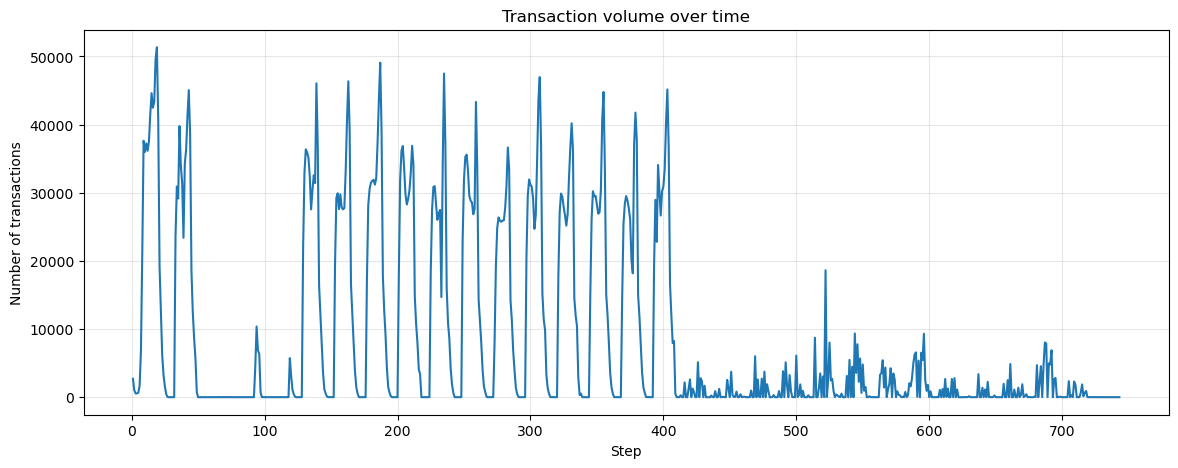

In [32]:
plt.figure(figsize=(14, 5))

plt.plot(
    time_activity.index,
    time_activity["transactions"]
)

plt.xlabel("Step")
plt.ylabel("Number of transactions")
plt.title("Transaction volume over time")
plt.grid(alpha=0.3)

plt.show()

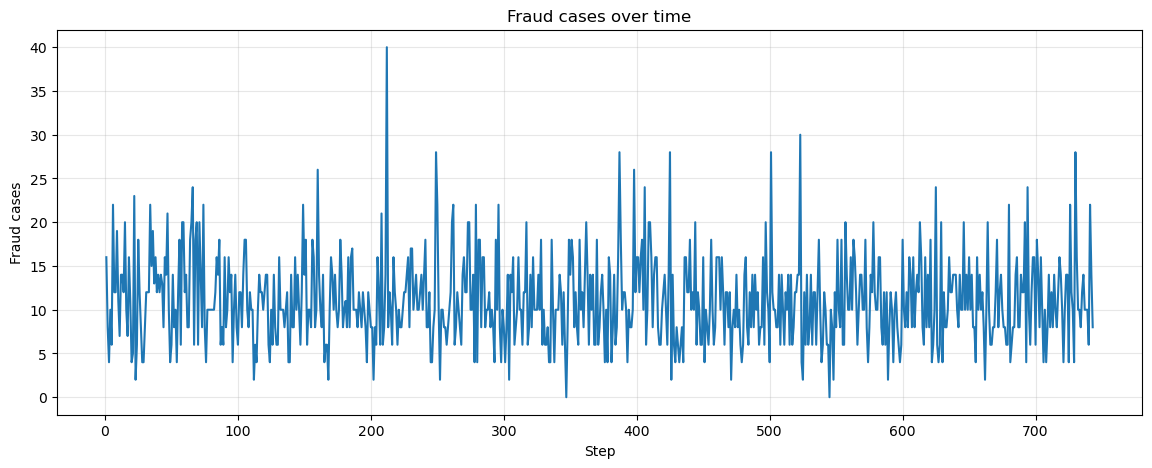

In [33]:
plt.figure(figsize=(14, 5))

plt.plot(
    time_activity.index,
    time_activity["fraud_cases"]
)

plt.xlabel("Step")
plt.ylabel("Fraud cases")
plt.title("Fraud cases over time")
plt.grid(alpha=0.3)

plt.show()

In [34]:
sender_stats = (
    df.groupby("nameOrig")
      .agg(
          transactions=("nameOrig", "size"),
          total_amount=("amount", "sum"),
          avg_amount=("amount", "mean"),
          fraud_cases=("isFraud", "sum")
      )
)

print("Sender statistics:")
print(sender_stats.describe())

print("\nSenders with most transactions:")
print(
    sender_stats
    .sort_values("transactions", ascending=False)
    .head(20)
)

print("\nSenders with fraud:")
print(
    sender_stats[sender_stats["fraud_cases"] > 0]
    .sort_values("fraud_cases", ascending=False)
    .head(20)
)

Sender statistics:
       transactions  total_amount    avg_amount  fraud_cases
count  6353307.0000  6353307.0000  6353307.0000 6353307.0000
mean         1.0015   180125.5543   179857.0856       0.0013
std          0.0383   604338.1245   603402.0219       0.0359
min          1.0000        0.0000        0.0000       0.0000
25%          1.0000    13414.8800    13407.5300       0.0000
50%          1.0000    75068.4700    74974.3900       0.0000
75%          1.0000   208994.8400   208698.2100       0.0000
max          3.0000 92445516.6400 92445516.6400       1.0000

Senders with most transactions:
             transactions  total_amount  avg_amount  fraud_cases
nameOrig                                                        
C1065307291             3   113479.2800  37826.4267            0
C1784010646             3   436700.2500 145566.7500            0
C1902386530             3   763712.7900 254570.9300            0
C1832548028             3   313665.8300 104555.2767            0
C54531511

In [35]:
receiver_stats = (
    df.groupby("nameDest")
      .agg(
          transactions=("nameDest", "size"),
          total_amount=("amount", "sum"),
          avg_amount=("amount", "mean"),
          fraud_cases=("isFraud", "sum")
      )
)

print("Receiver statistics:")
print(receiver_stats.describe())

print("\nReceivers with most transactions:")
print(
    receiver_stats
    .sort_values("transactions", ascending=False)
    .head(20)
)

print("\nReceivers associated with fraud:")
print(
    receiver_stats[receiver_stats["fraud_cases"] > 0]
    .sort_values("fraud_cases", ascending=False)
    .head(20)
)

Receiver statistics:
       transactions   total_amount    avg_amount  fraud_cases
count  2722362.0000   2722362.0000  2722362.0000 2722362.0000
mean         2.3372    420367.6604    59621.8552       0.0030
std          4.5493   2061382.2215   197555.2113       0.0551
min          1.0000         0.0000        0.0000       0.0000
25%          1.0000      5588.6300     5586.0500       0.0000
50%          1.0000     12992.9350    12978.1000       0.0000
75%          1.0000     35493.9750    35004.2325       0.0000
max        113.0000 357440831.4400 20706948.1950       2.0000

Receivers with most transactions:
             transactions   total_amount   avg_amount  fraud_cases
nameDest                                                          
C1286084959           113  77428943.3100  685211.8877            0
C985934102            109  42422887.9800  389200.8072            0
C665576141            105  88749384.3800  845232.2322            0
C2083562754           102  53073938.7600  520332.73

In [36]:
df["amount_to_oldbalance_ratio"] = np.where(
    df["oldbalanceOrg"] > 0,
    df["amount"] / df["oldbalanceOrg"],
    np.nan
)

ratio_stats = (
    df.groupby("isFraud")["amount_to_oldbalance_ratio"]
      .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
)

print(ratio_stats)

               count     mean       std    min    25%    50%    75%     90%  \
isFraud                                                                       
0       4251999.0000 122.2727 4153.2591 0.0000 0.0743 0.7347 6.6847 39.6323   
1          8172.0000   0.9988    0.3853 0.0384 1.0000 1.0000 1.0000  1.0000   

             95%       99%          max  
isFraud                                  
0       177.2671 1678.0221 3925475.6000  
1         1.0000    1.0000      29.5266  


In [37]:
ratio_by_type = (
    df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
    .groupby(["type", "isFraud"])["amount_to_oldbalance_ratio"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
)

print(ratio_by_type)

                        count     mean        std    min    25%     50%  \
type     isFraud                                                          
CASH_OUT 0       1207622.0000 178.4423  4673.7351 0.0000 1.2974  4.7789   
         1          4079.0000   1.0122     0.5380 0.1234 1.0000  1.0000   
TRANSFER 0        246033.0000 762.9657 13014.0301 0.0000 4.0485 16.2255   
         1          4093.0000   0.9854     0.0877 0.0384 1.0000  1.0000   

                     75%      90%       95%        99%          max  
type     isFraud                                                     
CASH_OUT 0       18.0889 139.7643  507.8168  2403.2123 3925475.6000  
         1        1.0000   1.0000    1.0000     1.0000      29.5266  
TRANSFER 0       69.6206 472.5027 1757.5616 10777.5178 1854642.6700  
         1        1.0000   1.0000    1.0000     1.0000       1.5503  


In [38]:
zero_balance_fraud = df[
    (df["isFraud"] == 1) &
    (df["oldbalanceOrg"] == 0)
]

print("Fraud transactions with zero oldbalanceOrg:")
print(zero_balance_fraud.shape)

print("\nTransaction types:")
print(zero_balance_fraud["type"].value_counts())

print("\nDetails:")
print(
    zero_balance_fraud[
        [
            "step",
            "type",
            "amount",
            "oldbalanceOrg",
            "newbalanceOrig",
            "oldbalanceDest",
            "newbalanceDest",
            "isFlaggedFraud"
        ]
    ]
)

Fraud transactions with zero oldbalanceOrg:
(41, 15)

Transaction types:
type
CASH_OUT    37
TRANSFER     4
Name: count, dtype: int64

Details:
         step      type       amount  oldbalanceOrg  newbalanceOrig  \
724         1  CASH_OUT  416001.3300         0.0000          0.0000   
14861       8  CASH_OUT  181728.1100         0.0000          0.0000   
25875       8  TRANSFER 1078013.7600         0.0000          0.0000   
77745      10  CASH_OUT  277970.8800         0.0000          0.0000   
138559     11  TRANSFER 1933920.8000         0.0000          0.0000   
169998     12  CASH_OUT  149668.6600         0.0000          0.0000   
178668     12  CASH_OUT  222048.7100         0.0000          0.0000   
200845     13  CASH_OUT  454859.3900         0.0000          0.0000   
291459     15  CASH_OUT   95428.3200         0.0000          0.0000   
296686     15  CASH_OUT   39713.2800         0.0000          0.0000   
424928     18  CASH_OUT  508782.2000         0.0000          0.0000   
4796

In [39]:
balance_depletion = pd.Series(
    np.isclose(
        df["amount"],
        df["oldbalanceOrg"],
        rtol=1e-4,
        atol=0.01
    ),
    index=df.index
)

print("Overall:")
print(balance_depletion.value_counts())

print("\nBy fraud status:")
print(
    pd.crosstab(
        df["isFraud"],
        balance_depletion,
        normalize="index"
    ) * 100
)

print("\nBy transaction type and fraud:")
print(
    pd.crosstab(
        [df["type"], df["isFraud"]],
        balance_depletion,
        normalize="index"
    ) * 100
)

Overall:
False    6354512
True        8108
Name: count, dtype: int64

By fraud status:
col_0     False   True 
isFraud                
0       99.9988  0.0012
1        2.1795 97.8205

By transaction type and fraud:
col_0              False   True 
type     isFraud                
CASH_IN  0       99.9987  0.0013
CASH_OUT 0       99.9988  0.0012
         1        0.6074 99.3926
DEBIT    0       99.9976  0.0024
PAYMENT  0       99.9988  0.0012
TRANSFER 0       99.9994  0.0006
         1        3.7588 96.2412


In [40]:
# Origin balance residual
df["origin_residual"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

# Destination balance residual
df["destination_residual"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

print("Origin residual by transaction type:")
print(
    df.groupby("type")["origin_residual"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

print("\nDestination residual by transaction type:")
print(
    df.groupby("type")["destination_residual"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

Origin residual by transaction type:
            count         mean       median          std            min  \
type                                                                      
CASH_IN   1399284 -337835.4458 -286848.8200  253012.9095  -3830535.8000   
CASH_OUT  2237500 -147724.3523 -119512.3200  132305.0690  -2847566.6200   
DEBIT       41432   -1997.9802       0.0000   10830.2917   -569077.5100   
PAYMENT   2151495   -6678.6680    -380.7800   11178.1119   -238637.9800   
TRANSFER   532909 -866493.3146 -448795.4600 1868800.5837 -92445516.6400   

             max  
type              
CASH_IN  -0.0800  
CASH_OUT  0.0100  
DEBIT     0.0100  
PAYMENT   0.0100  
TRANSFER  0.0100  

Destination residual by transaction type:
            count        mean      median          std            min  \
type                                                                    
CASH_IN   1399284 289733.6533 248899.8100  339699.4029 -56707338.1500   
CASH_OUT  2237500 -17294.2164      0.0000 

In [41]:
print("\nOrigin residual by type and fraud:")
print(
    df.groupby(["type", "isFraud"])["origin_residual"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

print("\nDestination residual by type and fraud:")
print(
    df.groupby(["type", "isFraud"])["destination_residual"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)


Origin residual by type and fraud:
                    count         mean       median          std  \
type     isFraud                                                   
CASH_IN  0        1399284 -337835.4458 -286848.8200  253012.9095   
CASH_OUT 0        2233384 -147994.1928 -119824.2150  132274.4172   
         1           4116   -1306.1252       0.0000   20673.8534   
DEBIT    0          41432   -1997.9802       0.0000   10830.2917   
PAYMENT  0        2151495   -6678.6680    -380.7800   11178.1119   
TRANSFER 0         528812 -873050.6224 -454033.0800 1874244.7519   
         1           4097  -20122.0542       0.0000  374621.6121   

                            min     max  
type     isFraud                         
CASH_IN  0        -3830535.8000 -0.0800  
CASH_OUT 0        -2847566.6200  0.0100  
         1         -577418.9800  0.0000  
DEBIT    0         -569077.5100  0.0100  
PAYMENT  0         -238637.9800  0.0100  
TRANSFER 0       -92445516.6400  0.0100  
         1     

In [42]:
df["expected_newbalanceOrig"] = (
    df["oldbalanceOrg"] - df["amount"]
)

df["origin_gap"] = (
    df["newbalanceOrig"] - df["expected_newbalanceOrig"]
)

df["sender_insufficient_balance"] = (
    df["amount"] > df["oldbalanceOrg"]
)

print("Sender insufficient balance:")
print(
    pd.crosstab(
        [df["type"], df["isFraud"]],
        df["sender_insufficient_balance"],
        normalize="index"
    ) * 100
)

print("\nOrigin gap by type and fraud:")
print(
    df.groupby(["type", "isFraud"])["origin_gap"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

Sender insufficient balance:
sender_insufficient_balance   False   True 
type     isFraud                           
CASH_IN  0                  65.8728 34.1272
CASH_OUT 0                  11.2961 88.7039
         1                  99.4169  0.5831
DEBIT    0                  71.5534 28.4466
PAYMENT  0                  48.8205 51.1795
TRANSFER 0                   4.0288 95.9712
         1                  99.8780  0.1220

Origin gap by type and fraud:
                    count        mean      median          std     min  \
type     isFraud                                                         
CASH_IN  0        1399284 337835.4458 286848.8200  253012.9095  0.0800   
CASH_OUT 0        2233384 147994.1928 119824.2150  132274.4172 -0.0100   
         1           4116   1306.1252      0.0000   20673.8534  0.0000   
DEBIT    0          41432   1997.9802      0.0000   10830.2917 -0.0100   
PAYMENT  0        2151495   6678.6680    380.7800   11178.1119 -0.0100   
TRANSFER 0         528812 

In [43]:
df["amount_equals_oldbalance"] = np.isclose(
    df["amount"],
    df["oldbalanceOrg"],
    rtol=1e-4,
    atol=0.01
)

df["newbalance_is_zero"] = np.isclose(
    df["newbalanceOrig"],
    0,
    atol=0.01
)

print("Fraud by amount ≈ oldbalance AND newbalance ≈ 0:")
print(
    pd.crosstab(
        [df["type"], df["isFraud"]],
        [
            df["amount_equals_oldbalance"],
            df["newbalance_is_zero"]
        ],
        normalize="index"
    ) * 100
)

Fraud by amount ≈ oldbalance AND newbalance ≈ 0:
amount_equals_oldbalance   False          True         
newbalance_is_zero         False   True   False   True 
type     isFraud                                       
CASH_IN  0               99.9987  0.0000 0.0013  0.0000
CASH_OUT 0               11.2956 88.7032 0.0006  0.0006
         1                0.0243  0.5831 0.0000 99.3926
DEBIT    0               71.5534 28.4442 0.0000  0.0024
PAYMENT  0               48.8200 51.1788 0.0005  0.0007
TRANSFER 0                4.0288 95.9706 0.0000  0.0006
         1                3.6368  0.1220 0.2441 95.9971


In [44]:
fraud_types = ["CASH_OUT", "TRANSFER"]

dest_df = df[df["type"].isin(fraud_types)].copy()

dest_df["expected_newbalanceDest"] = (
    dest_df["oldbalanceDest"] + dest_df["amount"]
)

dest_df["dest_gap"] = (
    dest_df["newbalanceDest"]
    - dest_df["expected_newbalanceDest"]
)

print("Destination gap by type and fraud:")
print(
    dest_df.groupby(["type", "isFraud"])["dest_gap"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print("\nDestination balance ≈ expected balance:")
dest_df["dest_balance_matches"] = np.isclose(
    dest_df["newbalanceDest"],
    dest_df["expected_newbalanceDest"],
    rtol=1e-4,
    atol=0.01
)

print(
    pd.crosstab(
        [dest_df["type"], dest_df["isFraud"]],
        dest_df["dest_balance_matches"],
        normalize="index"
    ) * 100
)

Destination gap by type and fraud:
                    count          mean       median          std  \
type     isFraud                                                    
CASH_OUT 0        2233384    17308.5368       0.0000  261979.0821   
         1           4116     9523.8353       0.0000  215575.5973   
TRANSFER 0         528812    88356.1037       0.0000 1219878.1941   
         1           4097 -1477983.6455 -442722.0100 2416224.5172   

                            min           max  
type     isFraud                               
CASH_OUT 0        -9977761.0600 57787800.9300  
         1         -698001.8500  8875516.2900  
TRANSFER 0        -8247637.0000 75885725.6300  
         1       -10000000.0000  1645042.0900  

Destination balance ≈ expected balance:
dest_balance_matches   False   True 
type     isFraud                    
CASH_OUT 0            9.4658 90.5342
         1            3.4500 96.5500
TRANSFER 0           10.1985 89.8015
         1           99.9268  0.0732

In [45]:
dest_df["dest_amount_coverage"] = np.where(
    dest_df["amount"] > 0,
    (dest_df["newbalanceDest"] - dest_df["oldbalanceDest"])
    / dest_df["amount"],
    np.nan
)

print(
    dest_df.groupby(["type", "isFraud"])["dest_amount_coverage"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

                    count   mean  median      std         min        max
type     isFraud                                                        
CASH_OUT 0        2233384 1.4868  1.0000 109.4812 -80916.6329 96060.8760
         1           4100 1.1987  1.0000  14.1779   -397.9836   661.8890
TRANSFER 0         528812 1.3320  1.0000 120.7376  -4757.8628 85415.6214
         1           4097 0.4713  0.0000  20.7808     -2.2081  1203.1315


In [46]:
print(
    dest_df.loc[
        dest_df["dest_amount_coverage"].abs() > 10,
        [
            "step",
            "type",
            "amount",
            "oldbalanceDest",
            "newbalanceDest",
            "isFraud",
            "dest_amount_coverage"
        ]
    ]
    .sort_values("dest_amount_coverage")
    .head(20)
)

         step      type   amount  oldbalanceDest  newbalanceDest  isFraud  \
101259     10  CASH_OUT   1.5800     197938.4800      70090.2000        0   
4411933   322  CASH_OUT   6.8300     151002.0000      13941.5100        0   
4249407   306  CASH_OUT  12.3400     146812.0700          0.0000        0   
4068711   300  CASH_OUT  15.0700     278158.2500     196051.2700        0   
2441478   203  TRANSFER  74.1300    2359375.8400    2006675.4700        0   
1751077   161  CASH_OUT  28.7500     117385.0000          0.0000        0   
149778     12  CASH_OUT  28.8700      94782.0000          0.0000        0   
5159254   357  CASH_OUT  39.4300    4268907.6000    4140999.8900        0   
461949     19  CASH_OUT  84.2400    7007241.2900    6741373.4100        0   
1402575   139  CASH_OUT  52.5000     625967.0700     472767.5900        0   
121083     11  CASH_OUT  97.9200     885494.6700     636061.1800        0   
938109     43  CASH_OUT  49.8100    1113096.3600     996400.6300        0   

In [47]:
df["amount_oldbalance_diff"] = (
    df["oldbalanceOrg"] - df["amount"]
)

print(
    df.groupby(["type", "isFraud"])["amount_oldbalance_diff"]
      .agg([
          "count",
          "mean",
          "median",
          "std",
          "min",
          "max"
      ])
)

                    count         mean       median          std  \
type     isFraud                                                   
CASH_IN  0        1399284 3421543.2663 1031731.7200 5299178.7314   
CASH_OUT 0        2233384 -130487.9299 -119823.8300  186072.1510   
         1           4116   -1233.5383       0.0000   21196.3319   
DEBIT    0          41432   63163.6718   16632.4150  139021.6449   
PAYMENT  0        2151495   55159.2229    -380.7800  199390.5672   
TRANSFER 0         528812 -865670.2502 -454033.0800 1880032.2535   
         1           4097  365482.5145       0.0000 2716765.4437   

                            min           max  
type     isFraud                               
CASH_IN  0        -1026214.6200 38932615.0400  
CASH_OUT 0        -2847566.6200 43686616.3300  
         1         -577418.9800   298767.6100  
DEBIT    0         -569077.5100  4359375.1800  
PAYMENT  0         -238637.9800 43673802.2100  
TRANSFER 0       -92445516.6400 24777189.3300  
   

In [48]:
df["step_bucket"] = pd.cut(
    df["step"],
    bins=range(0, 761, 50),
    right=False
)

fraud_by_time = (
    df.groupby("step_bucket", observed=True)["isFraud"]
      .agg(
          transactions="count",
          fraud_cases="sum",
          fraud_rate="mean"
      )
)

fraud_by_time["fraud_rate_pct"] = fraud_by_time["fraud_rate"] * 100

print(fraud_by_time)

             transactions  fraud_cases  fraud_rate  fraud_rate_pct
step_bucket                                                       
[0, 50)           1030257          584      0.0006          0.0567
[50, 100)           29253          600      0.0205          2.0511
[100, 150)         451844          512      0.0011          0.1133
[150, 200)         870820          550      0.0006          0.0632
[200, 250)         834264          573      0.0007          0.0687
[250, 300)         826036          574      0.0007          0.0695
[300, 350)         873196          494      0.0006          0.0566
[350, 400)         840450          574      0.0007          0.0683
[400, 450)         258581          580      0.0022          0.2243
[450, 500)          40998          516      0.0126          1.2586
[500, 550)         105516          500      0.0047          0.4739
[550, 600)          97814          538      0.0055          0.5500
[600, 650)          22744          580      0.0255          2.

In [49]:
fraud_time_type = (
    df[df["type"].isin(["CASH_OUT", "TRANSFER"])]
    .assign(
        step_bucket=pd.cut(
            df.loc[df["type"].isin(["CASH_OUT", "TRANSFER"]), "step"],
            bins=range(0, 761, 50),
            right=False
        )
    )
    .groupby(["step_bucket", "type"], observed=True)["isFraud"]
    .agg(
        transactions="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
)

fraud_time_type["fraud_rate_pct"] = (
    fraud_time_type["fraud_rate"] * 100
)

print(fraud_time_type)

                      transactions  fraud_cases  fraud_rate  fraud_rate_pct
step_bucket type                                                           
[0, 50)     CASH_OUT        369089          299      0.0008          0.0810
            TRANSFER         84991          285      0.0034          0.3353
[50, 100)   CASH_OUT          6509          300      0.0461          4.6090
            TRANSFER          2715          300      0.1105         11.0497
[100, 150)  CASH_OUT        161476          256      0.0016          0.1585
            TRANSFER         37337          256      0.0069          0.6856
[150, 200)  CASH_OUT        310820          276      0.0009          0.0888
            TRANSFER         72383          274      0.0038          0.3785
[200, 250)  CASH_OUT        294389          288      0.0010          0.0978
            TRANSFER         68833          285      0.0041          0.4140
[250, 300)  CASH_OUT        291191          287      0.0010          0.0986
            

In [50]:
amount_by_time = (
    df.groupby("step_bucket", observed=True)["amount"]
      .agg(
          transactions="count",
          mean="mean",
          median="median",
          p90=lambda x: x.quantile(0.90),
          p99=lambda x: x.quantile(0.99)
      )
)

print(amount_by_time)

             transactions        mean     median         p90          p99
step_bucket                                                              
[0, 50)           1030257 158625.8127 77263.7900 373512.5300 1300245.4888
[50, 100)           29253 147793.5588 20346.0100 324822.3760 1790925.1204
[100, 150)         451844 165736.3992 81776.9900 384083.6160 1355466.5770
[150, 200)         870820 157465.4803 77531.3500 366768.0400 1274679.3579
[200, 250)         834264 152354.1749 71706.9950 351370.2610 1300322.4826
[250, 300)         826036 168132.1645 68613.6200 331985.8700 1331466.2030
[300, 350)         873196 279846.6169 81106.3150 398021.3000 4404122.4510
[350, 400)         840450 182953.5312 76347.1950 371380.4470 1924532.8188
[400, 450)         258581 156167.2554 67595.4300 338557.8200 1430151.3740
[450, 500)          40998 195177.6109 74122.1800 385246.6860 2232504.0913
[500, 550)         105516 171762.7275 69057.4050 349561.0850 1893192.3405
[550, 600)          97814 155247.7785 

In [51]:
print(df[
    [
        "type",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "isFraud",
        "isFlaggedFraud"
    ]
].head(20).to_string())

        type      amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud
0    PAYMENT   9839.6400    170136.0000     160296.3600          0.0000          0.0000        0               0
1    PAYMENT   1864.2800     21249.0000      19384.7200          0.0000          0.0000        0               0
2   TRANSFER    181.0000       181.0000          0.0000          0.0000          0.0000        1               0
3   CASH_OUT    181.0000       181.0000          0.0000      21182.0000          0.0000        1               0
4    PAYMENT  11668.1400     41554.0000      29885.8600          0.0000          0.0000        0               0
5    PAYMENT   7817.7100     53860.0000      46042.2900          0.0000          0.0000        0               0
6    PAYMENT   7107.7700    183195.0000     176087.2300          0.0000          0.0000        0               0
7    PAYMENT   7861.6400    176087.2300     168225.5900          0.0000          0.0000        0

In [52]:
print("\nBalance availability patterns by transaction type:\n")

print(
    df.groupby("type")[
        [
            "oldbalanceOrg",
            "newbalanceOrig",
            "oldbalanceDest",
            "newbalanceDest"
        ]
    ].agg(["mean", "median"])
)


Balance availability patterns by transaction type:

         oldbalanceOrg              newbalanceOrig               \
                  mean       median           mean       median   
type                                                              
CASH_IN   3590463.5083 1200093.3200   3759378.7121 1369114.9250   
CASH_OUT    46023.8048     556.0000     17474.1927       0.0000   
DEBIT       68647.3371   20821.1100     65161.6520   16632.4150   
PAYMENT     68216.8276   10530.0000     61837.8909       0.0000   
TRANSFER    54441.8517       0.0000     10288.1567       0.0000   

         oldbalanceDest              newbalanceDest               
                   mean       median           mean       median  
type                                                              
CASH_IN    1587918.7965  547137.3100   1467105.3852  385751.3600  
CASH_OUT   1497757.8876  488098.5050   1691326.0684  687606.7100  
DEBIT      1493135.7713  424460.4100   1513003.4680  439328.8700  
PAYMENT 

In [53]:
balance_availability = pd.DataFrame({
    "column": [
        "oldbalanceOrg",
        "oldbalanceDest",
        "newbalanceOrig",
        "newbalanceDest"
    ],
    "zero_count": [
        (df["oldbalanceOrg"] == 0).sum(),
        (df["oldbalanceDest"] == 0).sum(),
        (df["newbalanceOrig"] == 0).sum(),
        (df["newbalanceDest"] == 0).sum()
    ],
    "zero_pct": [
        (df["oldbalanceOrg"] == 0).mean() * 100,
        (df["oldbalanceDest"] == 0).mean() * 100,
        (df["newbalanceOrig"] == 0).mean() * 100,
        (df["newbalanceDest"] == 0).mean() * 100
    ]
})

print(balance_availability)

           column  zero_count  zero_pct
0   oldbalanceOrg     2102449   33.0438
1  oldbalanceDest     2704388   42.5043
2  newbalanceOrig     3609566   56.7308
3  newbalanceDest     2439433   38.3401


Feature Engineering

In [54]:
df["amount_to_oldbalance_ratio"] = np.where(
    df["oldbalanceOrg"] > 0,
    df["amount"] / df["oldbalanceOrg"],
    np.nan
)

df["amount_to_oldbalance_ratio"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count   4260171.0000
mean        122.0401
std        4149.2771
min           0.0000
25%           0.0746
50%           0.7408
75%           6.6558
90%          39.4879
95%         176.5315
99%        1675.1712
max     3925475.6000
Name: amount_to_oldbalance_ratio, dtype: float64

In [55]:
df.groupby("isFraud")["amount_to_oldbalance_ratio"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
isFraud,,,,,,,,,,,
0,4251999.0000,122.2727,4153.2591,0.0000,0.0743,0.7347,6.6847,39.6323,177.2671,1678.0221,3925475.6000
1,8172.0000,0.9988,0.3853,0.0384,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,29.5266


In [56]:
df.groupby(["type", "isFraud"])["amount_to_oldbalance_ratio"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count     mean        std    min    25%     50%  \
type     isFraud                                                          
CASH_IN  0       1385820.0000  74.3400  1919.1172 0.0000 0.0228  0.1152   
CASH_OUT 0       1207622.0000 178.4423  4673.7351 0.0000 1.2974  4.7789   
         1          4079.0000   1.0122     0.5380 0.1234 1.0000  1.0000   
DEBIT    0         35274.0000   4.4754    72.7932 0.0000 0.0265  0.0994   
PAYMENT  0       1377250.0000   9.8154   220.2231 0.0000 0.0571  0.2196   
TRANSFER 0        246033.0000 762.9657 13014.0301 0.0000 4.0485 16.2255   
         1          4093.0000   0.9854     0.0877 0.0384 1.0000  1.0000   

                     75%      90%       95%        99%          max  
type     isFraud                                                     
CASH_IN  0        3.0461  20.0171   95.4311  1228.3828  548909.8100  
CASH_OUT 0       18.0889 139.7643  507.8168  2403.2123 3925475.6000  
         1        1.0000   1.0000    1.0000     1.0000      29.5266  
DEBIT    0        0.4067   3.1018   10.7876    61.9746    9241.3100  
PAYMENT  0        0.9130   5.2352   22.4708   142.3818   61766.5100  
TRANSFER 0       69.6206 472.5027 1757.5616 10777.5178 1854642.6700  
         1        1.0000   1.0000    1.0000     1.0000       1.5503

In [57]:
df["sender_balance_coverage"] = np.where(
    df["oldbalanceOrg"] > 0,
    np.minimum(
        df["amount"] / df["oldbalanceOrg"],
        1.0
    ),
    np.nan
)

In [58]:
df.groupby("isFraud")["sender_balance_coverage"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
isFraud,,,,,,,,,,,
0,4251999.0000,0.5746,0.4369,0.0000,0.0743,0.7347,1.0000,1.0000,1.0000,1.0000,1.0000
1,8172.0000,0.9925,0.0630,0.0384,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [59]:
pd.crosstab(
    df["isFraud"],
    df["sender_balance_coverage"].ge(0.99),
    normalize="index"
) * 100

sender_balance_coverage,False,True
isFraud,,
0,68.8170,31.1830
1,2.3256,97.6744


In [60]:
df["sender_balance_zero"] = (
    df["oldbalanceOrg"] == 0
).astype("int8")

In [61]:
pd.crosstab(
    df["isFraud"],
    df["sender_balance_zero"],
    normalize="index"
) * 100

sender_balance_zero,0,1
isFraud,,
0,66.9142,33.0858
1,99.5008,0.4992


In [62]:
pd.crosstab(
    [df["type"], df["isFraud"]],
    df["sender_balance_zero"],
    normalize="index"
) * 100

sender_balance_zero       0       1
type     isFraud                   
CASH_IN  0          99.0378  0.9622
CASH_OUT 0          54.0714 45.9286
         1          99.1011  0.8989
DEBIT    0          85.1371 14.8629
PAYMENT  0          64.0136 35.9864
TRANSFER 0          46.5256 53.4744
         1          99.9024  0.0976

In [63]:
df["amount_to_olddest_ratio"] = np.where(
    df["oldbalanceDest"] > 0,
    df["amount"] / df["oldbalanceDest"],
    np.nan
)

In [64]:
df.groupby("isFraud")["amount_to_olddest_ratio"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
isFraud,,,,,,,,,,,
0,3655370.0000,10.2561,3880.0960,0.0000,0.0655,0.2110,0.5664,1.1786,3.5847,30.3637,5542638.6667
1,2862.0000,69.8954,1957.9966,0.0000,0.1806,0.9931,5.7454,26.3958,67.6346,575.8377,103325.5185


In [65]:
df.groupby(["type", "isFraud"])["amount_to_olddest_ratio"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    mean       std    min    25%    50%    75%  \
type     isFraud                                                              
CASH_IN  0       1235711.0000 10.1147 5105.4750 0.0000 0.0596 0.1868 0.5042   
CASH_OUT 0       1910456.0000  8.3253 3349.9044 0.0000 0.0628 0.1995 0.5500   
         1          2857.0000 70.0134 1959.7077 0.0000 0.1806 0.9922 5.7607   
DEBIT    0         41432.0000  0.0418    0.1089 0.0000 0.0017 0.0067 0.0274   
PAYMENT  0             0.0000     NaN       NaN    NaN    NaN    NaN    NaN   
TRANSFER 0        467771.0000 19.4200 1719.6813 0.0000 0.1513 0.3928 0.7987   
         1             5.0000  2.4577    2.5899 0.0956 0.2299 1.5064 5.1047   

                     90%     95%      99%          max  
type     isFraud                                        
CASH_IN  0        0.9480  2.4178  19.5010 5542638.6667  
CASH_OUT 0        1.2262  3.4513  26.0988 4276570.0000  
         1       26.4390 67.7787 577.1684  103325.5185  
DEBIT    0        0.0980  0.2059   0.6294       0.9996  
PAYMENT  0           NaN     NaN      NaN          NaN  
TRANSFER 0        3.0783 10.3168  91.3491  785109.6600  
         1        5.2531  5.3026   5.3422       5.3521

In [66]:
dest_ratio = df["amount_to_olddest_ratio"]

pd.crosstab(
    df["isFraud"],
    dest_ratio.ge(0.99),
    normalize="index"
) * 100

amount_to_olddest_ratio,False,True
isFraud,,
0,93.5693,6.4307
1,82.5521,17.4479


In [67]:
pd.crosstab(
    df["isFraud"],
    df["oldbalanceDest"].eq(0),
    normalize="index"
) * 100

oldbalanceDest,False,True
isFraud,,
0,57.5250,42.4750
1,34.8472,65.1528


In [68]:
mask = df["type"].isin(["CASH_OUT", "TRANSFER"])

pd.crosstab(
    [df.loc[mask, "type"], df.loc[mask, "isFraud"]],
    df.loc[mask, "oldbalanceDest"].eq(0),
    normalize="index"
) * 100

oldbalanceDest     False   True 
type     isFraud                
CASH_OUT 0       85.5409 14.4591
         1       69.4121 30.5879
TRANSFER 0       88.4570 11.5430
         1        0.1220 99.8780

In [69]:
df["destination_balance_zero"] = (
    df["oldbalanceDest"] == 0
).astype("int8")

In [70]:
pd.crosstab(
    [df["type"], df["isFraud"]],
    df["destination_balance_zero"],
    normalize="index"
) * 100

destination_balance_zero        0        1
type     isFraud                          
CASH_IN  0                88.3102  11.6898
CASH_OUT 0                85.5409  14.4591
         1                69.4121  30.5879
DEBIT    0               100.0000   0.0000
PAYMENT  0                 0.0000 100.0000
TRANSFER 0                88.4570  11.5430
         1                 0.1220  99.8780

In [71]:
df["log_amount"] = np.log1p(df["amount"])

In [72]:
df.groupby("isFraud")[["amount", "log_amount"]].agg(
    ["mean", "median", "std", "min", "max"]
)

amount                                               log_amount  \
                mean      median          std    min           max       mean   
isFraud                                                                         
0        178197.0417  74684.7200  596236.9813 0.0100 92445516.6400    10.8382   
1       1467967.2991 441423.4400 2404252.9472 0.0000 10000000.0000    12.8920   

                                       
         median    std    min     max  
isFraud                                
0       11.2210 1.8128 0.0100 18.3421  
1       12.9978 1.9427 0.0000 16.1181

In [73]:
df.groupby("isFraud")["log_amount"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
isFraud,,,,,,,,,,,
0,6354407.0000,10.8382,1.8128,0.0100,9.5007,11.2210,12.2471,12.8059,13.1531,14.2768,18.3421
1,8213.0000,12.8920,1.9427,0.0000,11.7527,12.9978,14.2328,15.3244,15.8958,16.1181,16.1181


In [74]:
df.groupby("isFraud")["step"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
isFraud,,,,,,,,,,,
0,6354407.0000,243.2357,142.1402,1.0000,156.0000,239.0000,334.0000,398.0000,490.0000,681.0000,718.0000
1,8213.0000,368.4139,216.3887,1.0000,181.0000,367.0000,558.0000,671.0000,707.0000,736.0000,743.0000


In [75]:
df.groupby(["type", "isFraud"])["step"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

count     mean   median      std  min  max
type     isFraud                                              
CASH_IN  0        1399284 244.4901 249.0000 142.9260    1  718
CASH_OUT 0        2233384 240.6670 236.0000 140.4922    1  718
         1           4116 367.7204 367.0000 216.6702    1  743
DEBIT    0          41432 248.4405 252.0000 149.8436    1  718
PAYMENT  0        2151495 244.3782 249.0000 142.6951    1  718
TRANSFER 0         528812 245.7086 249.0000 143.9223    1  718
         1           4097 369.1106 369.0000 216.1297    1  743

In [76]:
df.groupby(["type", "isFraud"]).size().unstack(fill_value=0)

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [77]:
pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
type,,
CASH_IN,100.0000,0.0000
CASH_OUT,99.8160,0.1840
DEBIT,100.0000,0.0000
PAYMENT,100.0000,0.0000
TRANSFER,99.2312,0.7688


In [78]:
df.groupby("isFraud")["oldbalanceOrg"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
isFraud,,,,,,,,,,,
0,6354407.0000,832828.7117,2887144.0304,0.0000,0.0000,14069.0000,106969.5000,1813994.2780,5819680.5680,16028768.8088,43818855.3000
1,8213.0000,1649667.6057,3547719.4391,0.0000,125822.4400,438983.4500,1517771.4800,4525901.2500,8020192.1500,15490195.2816,59585040.3700


In [79]:
df.groupby(["type", "isFraud"])["oldbalanceOrg"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

count         mean       median          std    min  \
type     isFraud                                                          
CASH_IN  0        1399284 3590463.5083 1200093.3200 5291824.9049 0.0000   
CASH_OUT 0        2233384   43429.2259     539.0000  133880.1618 0.0000   
         1           4116 1453869.0476  433677.7450 2394505.6101 0.0000   
DEBIT    0          41432   68647.3371   20821.1100  138449.2767 0.0000   
PAYMENT  0        2151495   68216.8276   10530.0000  198991.0808 0.0000   
TRANSFER 0         528812   40558.7576       0.0000  140618.5549 0.0000   
         1           4097 1846374.1874  444898.9700 4404157.3746 0.0000   

                           max  
type     isFraud                
CASH_IN  0       38939424.0300  
CASH_OUT 0       43818855.3000  
         1       10000000.0000  
DEBIT    0        4362014.1100  
PAYMENT  0       43686616.3300  
TRANSFER 0       25908675.0600  
         1       59585040.3700

In [80]:
df.groupby("isFraud")["oldbalanceDest"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
isFraud,,,,,,,,,,,
0,6354407.0000,1101420.8746,3399201.7933,0.0000,0.0000,133311.8000,944144.5800,2916159.2780,5149910.3790,12375859.9102,356015889.3500
1,8213.0000,544249.6191,3336420.9509,0.0000,0.0000,0.0000,147828.6600,1124268.0480,2654963.4280,9341999.9808,236230516.8200


In [81]:
df.groupby(["type", "isFraud"])["oldbalanceDest"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

count         mean       median          std     min  \
type     isFraud                                                           
CASH_IN  0        1399284 1587918.7965  547137.3100 3713923.2512  0.0000   
CASH_OUT 0        2233384 1498518.7272  488830.9650 3631698.2280  0.0000   
         1           4116 1084918.4815  144970.0550 4650482.0778  0.0000   
DEBIT    0          41432 1493135.7713  424460.4100 4386970.3036 85.0000   
PAYMENT  0        2151495       0.0000       0.0000       0.0000  0.0000   
TRANSFER 0         528812 2587490.0715 1032056.7050 6056945.2320  0.0000   
         1           4097    1073.3833       0.0000   39961.0264  0.0000   

                            max  
type     isFraud                 
CASH_IN  0       355553416.3000  
CASH_OUT 0       356015889.3500  
         1       236230516.8200  
DEBIT    0       327827763.4200  
PAYMENT  0               0.0000  
TRANSFER 0       355380483.5300  
         1         2122336.5500

In [82]:
dest_stats = (
    df.groupby("nameDest")
      .agg(
          transactions=("nameDest", "size"),
          fraud_count=("isFraud", "sum")
      )
)

dest_stats["fraud_rate"] = (
    dest_stats["fraud_count"] / dest_stats["transactions"]
)

dest_stats.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,transactions,fraud_count,fraud_rate
count,2722362.0000,2722362.0000,2722362.0000
mean,2.3372,0.0030,0.0014
std,4.5493,0.0551,0.0331
min,1.0000,0.0000,0.0000
50%,1.0000,0.0000,0.0000
75%,1.0000,0.0000,0.0000
90%,5.0000,0.0000,0.0000
95%,10.0000,0.0000,0.0000
99%,25.0000,0.0000,0.0000
max,113.0000,2.0000,1.0000


In [83]:
dest_stats.sort_values(
    ["fraud_count", "transactions"],
    ascending=[False, False]
).head(20)

,transactions,fraud_count,fraud_rate
nameDest,,,
C803116137,77,2,0.0260
C410033330,48,2,0.0417
C185805228,47,2,0.0426
C2020337583,41,2,0.0488
C1193568854,37,2,0.0541
C1013511446,35,2,0.0571
C1655359478,34,2,0.0588
C200064275,33,2,0.0606
C1325541393,32,2,0.0625


In [84]:
step_distribution = (
    df.groupby("step")
      .agg(
          transactions=("step", "size"),
          fraud_count=("isFraud", "sum")
      )
)

step_distribution["fraud_rate"] = (
    step_distribution["fraud_count"]
    / step_distribution["transactions"]
)

step_distribution

,transactions,fraud_count,fraud_rate
step,,,
1,2708,16,0.0059
2,1014,8,0.0079
3,552,4,0.0072
4,565,10,0.0177
5,665,6,0.0090
...,...,...,...
739,10,10,1.0000
740,6,6,1.0000
741,22,22,1.0000


In [85]:
print("Total transactions:", len(df))
print("Total fraud:", df["isFraud"].sum())

print("\nStep range:")
print(df["step"].min(), "→", df["step"].max())

print("\nTransactions by broad time region:")

print(
    df.assign(
        period=pd.cut(
            df["step"],
            bins=[0, 250, 500, 750],
            labels=["early", "middle", "late"],
            right=False
        )
    )
    .groupby("period", observed=True)["isFraud"]
    .agg(
        transactions="size",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

Total transactions: 6362620
Total fraud: 8213

Step range:
1 → 743

Transactions by broad time region:
        transactions  fraud_count  fraud_rate
period                                       
early        3216438         2819      0.0009
middle       2839261         2738      0.0010
late          306921         2656      0.0087


In [86]:
train_df = df[df["step"] <= 499].copy()

val_df = df[
    (df["step"] >= 500) &
    (df["step"] <= 599)
].copy()

test_df = df[df["step"] >= 600].copy()

In [87]:
for name, data in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df),
]:
    print(f"\n{name}")
    print("Rows:", len(data))
    print("Fraud:", data["isFraud"].sum())
    print("Fraud rate:", data["isFraud"].mean())
    print("Step:", data["step"].min(), "→", data["step"].max())


TRAIN
Rows: 6055699
Fraud: 5557
Fraud rate: 0.000917647987457765
Step: 1 → 499

VALIDATION
Rows: 203330
Fraud: 1038
Fraud rate: 0.005105001721339694
Step: 500 → 599

TEST
Rows: 103591
Fraud: 1618
Fraud rate: 0.015619117490901719
Step: 600 → 743


In [88]:
print(
    "Overlap:",
    set(train_df.index) & set(val_df.index),
    set(train_df.index) & set(test_df.index),
    set(val_df.index) & set(test_df.index)
)

Overlap: set() set() set()


In [89]:
features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "sender_balance_coverage",
    "sender_balance_zero",
    "destination_balance_zero",
]

In [90]:
target = "isFraud"

In [91]:
features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "sender_balance_coverage",
    "sender_balance_zero",
    "destination_balance_zero",
]

print("Missing candidate features:")
print(df[features].isna().sum())

print("\nFeature dtypes:")
print(df[features].dtypes)

print("\nTarget:")
print(df["isFraud"].value_counts())

Missing candidate features:
step                              0
type                              0
amount                            0
oldbalanceOrg                     0
oldbalanceDest                    0
sender_balance_coverage     2102449
sender_balance_zero               0
destination_balance_zero          0
dtype: int64

Feature dtypes:
step                          int64
type                         object
amount                      float64
oldbalanceOrg               float64
oldbalanceDest              float64
sender_balance_coverage     float64
sender_balance_zero            int8
destination_balance_zero       int8
dtype: object

Target:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [92]:
print(
    "Coverage NaN but sender balance non-zero:",
    (
        df["sender_balance_coverage"].isna()
        & df["oldbalanceOrg"].ne(0)
    ).sum()
)

print(
    "Coverage present but sender balance zero:",
    (
        df["sender_balance_coverage"].notna()
        & df["oldbalanceOrg"].eq(0)
    ).sum()
)

Coverage NaN but sender balance non-zero: 0
Coverage present but sender balance zero: 0


In [93]:
features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "sender_balance_coverage",
    "sender_balance_zero",
    "destination_balance_zero",
]

target = "isFraud"

X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_val = val_df[features].copy()
y_val = val_df[target].copy()

X_test = test_df[features].copy()
y_test = test_df[target].copy()

In [94]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [95]:
categorical_features = ["type"]

numeric_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "sender_balance_coverage",
    "sender_balance_zero",
    "destination_balance_zero",
]

In [96]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)

In [97]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [98]:
print("Original features:", len(features))
print("Processed train shape:", X_train_processed.shape)
print("Processed val shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Original features: 8
Processed train shape: (6055699, 12)
Processed val shape: (203330, 12)
Processed test shape: (103591, 12)


In [99]:
print("\nFeature names:")
print(preprocessor.get_feature_names_out())


Feature names:
['categorical__type_CASH_IN' 'categorical__type_CASH_OUT'
 'categorical__type_DEBIT' 'categorical__type_PAYMENT'
 'categorical__type_TRANSFER' 'numeric__step' 'numeric__amount'
 'numeric__oldbalanceOrg' 'numeric__oldbalanceDest'
 'numeric__sender_balance_coverage' 'numeric__sender_balance_zero'
 'numeric__destination_balance_zero']


In [100]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 6050142
Positive samples: 5557
scale_pos_weight: 1088.742486953392


In [101]:
from xgboost import XGBClassifier

baseline_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
)

baseline_model.fit(
    X_train_processed,
    y_train,
    eval_set=[(X_val_processed, y_val)],
    verbose=50,
)

[0]	validation_0-aucpr:0.73536
[50]	validation_0-aucpr:0.94065
[100]	validation_0-aucpr:0.95936
[150]	validation_0-aucpr:0.96738
[200]	validation_0-aucpr:0.97207
[250]	validation_0-aucpr:0.97613
[300]	validation_0-aucpr:0.97762
[350]	validation_0-aucpr:0.97798
[400]	validation_0-aucpr:0.97878
[450]	validation_0-aucpr:0.97925
[500]	validation_0-aucpr:0.97990
[550]	validation_0-aucpr:0.98014
[600]	validation_0-aucpr:0.98045
[650]	validation_0-aucpr:0.98092
[700]	validation_0-aucpr:0.98092
[750]	validation_0-aucpr:0.98096
[756]	validation_0-aucpr:0.98089


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [102]:
print("Best iteration:", baseline_model.best_iteration)
print("Best score:", baseline_model.best_score)

Best iteration: 706
Best score: 0.9810932516833967


In [103]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Test probabilities
y_test_proba = baseline_model.predict_proba(X_test_processed)[:, 1]

# Default 0.5 threshold
y_test_pred = (y_test_proba >= 0.5).astype(int)

print("Test PR-AUC:", average_precision_score(y_test, y_test_proba))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))

print("\nThreshold = 0.50")
print("Precision:", precision_score(y_test, y_test_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_test_pred, zero_division=0))
print("F1:", f1_score(y_test, y_test_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Test PR-AUC: 0.9909009966234951
Test ROC-AUC: 0.9998566054416329

Threshold = 0.50
Precision: 0.7586854460093897
Recall: 0.9987639060568603
F1: 0.8623265741728922

Confusion Matrix:
[[101459    514]
 [     2   1616]]


In [104]:
feature_names = preprocessor.get_feature_names_out()

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": baseline_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
)

importance_df

,feature,importance
9,numeric__sender_balance_coverage,0.3290
0,categorical__type_CASH_IN,0.3158
3,categorical__type_PAYMENT,0.1976
7,numeric__oldbalanceOrg,0.0331
4,categorical__type_TRANSFER,0.0319
1,categorical__type_CASH_OUT,0.0293
11,numeric__destination_balance_zero,0.0219
6,numeric__amount,0.0213
10,numeric__sender_balance_zero,0.0084
2,categorical__type_DEBIT,0.0060


In [105]:
print(importance_df.to_string(index=False))

                          feature  importance
 numeric__sender_balance_coverage      0.3290
        categorical__type_CASH_IN      0.3158
        categorical__type_PAYMENT      0.1976
           numeric__oldbalanceOrg      0.0331
       categorical__type_TRANSFER      0.0319
       categorical__type_CASH_OUT      0.0293
numeric__destination_balance_zero      0.0219
                  numeric__amount      0.0213
     numeric__sender_balance_zero      0.0084
          categorical__type_DEBIT      0.0060
          numeric__oldbalanceDest      0.0033
                    numeric__step      0.0025


In [106]:
from sklearn.metrics import average_precision_score, roc_auc_score

rule_score = test_df["sender_balance_coverage"].fillna(0)

print("Rule PR-AUC:", average_precision_score(y_test, rule_score))
print("Rule ROC-AUC:", roc_auc_score(y_test, rule_score))

Rule PR-AUC: 0.041110268096099224
Rule ROC-AUC: 0.8120504328462235


In [107]:
coverage_bins = [
    -0.01,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.00
]

coverage_labels = [
    "0-10%",
    "10-25%",
    "25-50%",
    "50-75%",
    "75-90%",
    "90-95%",
    "95-99%",
    "99-100%"
]

df["coverage_band"] = pd.cut(
    df["sender_balance_coverage"],
    bins=coverage_bins,
    labels=coverage_labels,
    include_lowest=True,
)

In [108]:
coverage_analysis = (
    df[df["type"].isin(["CASH_OUT", "TRANSFER"])]
    .groupby(["type", "coverage_band"], observed=True)
    .agg(
        transactions=("isFraud", "size"),
        fraud_count=("isFraud", "sum"),
    )
    .reset_index()
)

coverage_analysis["fraud_rate"] = (
    coverage_analysis["fraud_count"]
    / coverage_analysis["transactions"]
)

coverage_analysis

,type,coverage_band,transactions,fraud_count,fraud_rate
0,CASH_OUT,0-10%,30574,0,0.0000
1,CASH_OUT,10-25%,45774,1,0.0000
2,CASH_OUT,25-50%,68903,0,0.0000
3,CASH_OUT,50-75%,58069,0,0.0000
4,CASH_OUT,75-90%,30204,0,0.0000
5,CASH_OUT,90-95%,9462,0,0.0000
6,CASH_OUT,95-99%,7476,0,0.0000
7,CASH_OUT,99-100%,961239,4078,0.0042
8,TRANSFER,0-10%,2232,1,0.0004
9,TRANSFER,10-25%,3434,9,0.0026


In [109]:
df["high_sender_coverage"] = (
    df["sender_balance_coverage"] >= 0.99
).astype("int8")

In [110]:
high_coverage_analysis = (
    df[df["type"].isin(["CASH_OUT", "TRANSFER"])]
    .groupby(["type", "high_sender_coverage"])
    .agg(
        transactions=("isFraud", "size"),
        fraud_count=("isFraud", "sum"),
        median_amount=("amount", "median"),
        mean_amount=("amount", "mean"),
    )
    .reset_index()
)

high_coverage_analysis["fraud_rate"] = (
    high_coverage_analysis["fraud_count"]
    / high_coverage_analysis["transactions"]
)

high_coverage_analysis

,type,high_sender_coverage,transactions,fraud_count,median_amount,mean_amount,fraud_rate
0,CASH_OUT,0,1276261,38,123523.9700,153126.8388,0.0000
1,CASH_OUT,1,961239,4078,177396.5700,207006.9804,0.0042
2,TRANSFER,0,304042,153,421962.1500,881638.0828,0.0005
3,TRANSFER,1,228867,3944,575873.3100,949184.3791,0.0172


In [111]:
high_cov = df[
    (df["type"].isin(["CASH_OUT", "TRANSFER"]))
    & (df["sender_balance_coverage"] >= 0.99)
].copy()

amount_bins = [
    0,
    10_000,
    50_000,
    100_000,
    250_000,
    500_000,
    1_000_000,
    2_000_000,
    5_000_000,
    10_000_000,
    np.inf,
]

amount_labels = [
    "<10K",
    "10K-50K",
    "50K-100K",
    "100K-250K",
    "250K-500K",
    "500K-1M",
    "1M-2M",
    "2M-5M",
    "5M-10M",
    "10M+",
]

high_cov["amount_band"] = pd.cut(
    high_cov["amount"],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True,
)

In [112]:
amount_coverage_analysis = (
    high_cov
    .groupby(["type", "amount_band"], observed=True)
    .agg(
        transactions=("isFraud", "size"),
        fraud_count=("isFraud", "sum"),
        median_coverage=("sender_balance_coverage", "median"),
    )
    .reset_index()
)

amount_coverage_analysis["fraud_rate"] = (
    amount_coverage_analysis["fraud_count"]
    / amount_coverage_analysis["transactions"]
)

amount_coverage_analysis

,type,amount_band,transactions,fraud_count,median_coverage,fraud_rate
0,CASH_OUT,<10K,6734,131,1.0000,0.0195
1,CASH_OUT,10K-50K,80156,378,1.0000,0.0047
2,CASH_OUT,50K-100K,150203,334,1.0000,0.0022
3,CASH_OUT,100K-250K,428802,700,1.0000,0.0016
4,CASH_OUT,250K-500K,264359,613,1.0000,0.0023
5,CASH_OUT,500K-1M,29619,577,1.0000,0.0195
6,CASH_OUT,1M-2M,532,511,1.0000,0.9605
7,CASH_OUT,2M-5M,465,465,1.0000,1.0000
8,CASH_OUT,5M-10M,369,369,1.0000,1.0000
9,TRANSFER,<10K,520,131,1.0000,0.2519


In [113]:
df["sender_amount_ratio"] = np.where(
    df["oldbalanceOrg"] > 0,
    df["amount"] / df["oldbalanceOrg"],
    np.nan,
)

df["log_sender_amount_ratio"] = np.log1p(
    df["sender_amount_ratio"]
)

In [114]:
ratio_stats = (
    df[df["type"].isin(["CASH_OUT", "TRANSFER"])]
    .groupby("isFraud")["sender_amount_ratio"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

ratio_stats

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
isFraud,,,,,,,,,,,
0,1453655.0000,277.3737,6845.4286,0.0000,1.5132,5.7758,23.6704,182.6119,634.3079,3509.9804,3925475.6000
1,8172.0000,0.9988,0.3853,0.0384,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,29.5266


In [115]:
log_ratio_stats = (
    df[df["type"].isin(["CASH_OUT", "TRANSFER"])]
    .groupby("isFraud")["log_sender_amount_ratio"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

log_ratio_stats

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
isFraud,,,,,,,,,,,
0,1453655.0000,2.3646,1.9113,0.0000,0.9215,1.9134,3.2056,5.2128,6.4541,8.1637,15.1830
1,8172.0000,0.6895,0.0560,0.0377,0.6931,0.6931,0.6931,0.6931,0.6931,0.6931,3.4186


In [116]:
df["log_sender_amount_ratio"] = np.log1p(
    df["sender_amount_ratio"]
)

In [117]:
features_with_ratio = [
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "sender_balance_coverage",
    "log_sender_amount_ratio",
    "sender_balance_zero",
    "destination_balance_zero",
]

In [118]:
categorical_features = ["type"]

numeric_features = [
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "sender_balance_coverage",
    "log_sender_amount_ratio",
    "sender_balance_zero",
    "destination_balance_zero",
]

preprocessor_ratio = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)

In [119]:
for split_df in [train_df, val_df, test_df]:
    split_df["sender_amount_ratio"] = np.where(
        split_df["oldbalanceOrg"] > 0,
        split_df["amount"] / split_df["oldbalanceOrg"],
        np.nan,
    )

    split_df["log_sender_amount_ratio"] = np.log1p(
        split_df["sender_amount_ratio"]
    )

In [122]:
X_train_ratio = train_df[features_with_ratio].copy()
X_val_ratio = val_df[features_with_ratio].copy()
X_test_ratio = test_df[features_with_ratio].copy()

y_train_ratio = train_df[target].copy()
y_val_ratio = val_df[target].copy()
y_test_ratio = test_df[target].copy()

X_train_ratio_processed = preprocessor_ratio.fit_transform(X_train_ratio)
X_val_ratio_processed = preprocessor_ratio.transform(X_val_ratio)
X_test_ratio_processed = preprocessor_ratio.transform(X_test_ratio)

print(X_train_ratio_processed.shape)
print(X_val_ratio_processed.shape)
print(X_test_ratio_processed.shape)

(6055699, 12)
(203330, 12)
(103591, 12)


In [123]:
print("log_sender_amount_ratio" in df.columns)
print(df[["sender_amount_ratio", "log_sender_amount_ratio"]].head())

True
   sender_amount_ratio  log_sender_amount_ratio
0               0.0578                   0.0562
1               0.0877                   0.0841
2               1.0000                   0.6931
3               1.0000                   0.6931
4               0.2808                   0.2475


In [124]:
X_train_ratio.columns


Index(['type', 'amount', 'oldbalanceOrg', 'oldbalanceDest',
       'sender_balance_coverage', 'log_sender_amount_ratio',
       'sender_balance_zero', 'destination_balance_zero'],
      dtype='object')

In [125]:
final_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
)

final_model.fit(
    X_train_ratio_processed,
    y_train_ratio,
    eval_set=[(X_val_ratio_processed, y_val_ratio)],
    verbose=False,
)

print("Best iteration:", final_model.best_iteration)
print("Best validation PR-AUC:", final_model.best_score)

Best iteration: 120
Best validation PR-AUC: 0.9869270944259924


In [127]:
from sklearn.metrics import classification_report, confusion_matrix
final_test_proba = final_model.predict_proba(
    X_test_ratio_processed
)[:, 1]

final_test_pred = (final_test_proba >= 0.5).astype(int)

print(
    "Test PR-AUC:",
    average_precision_score(
        y_test_ratio,
        final_test_proba,
    )
)

print(
    "Test ROC-AUC:",
    roc_auc_score(
        y_test_ratio,
        final_test_proba,
    )
)

print(
    classification_report(
        y_test_ratio,
        final_test_pred,
        digits=4,
    )
)

print(
    confusion_matrix(
        y_test_ratio,
        final_test_pred,
    )
)

Test PR-AUC: 0.9939170828461817
Test ROC-AUC: 0.9998841491489112
              precision    recall  f1-score   support

           0     1.0000    0.9991    0.9995    101973
           1     0.9477    0.9969    0.9717      1618

    accuracy                         0.9991    103591
   macro avg     0.9738    0.9980    0.9856    103591
weighted avg     0.9991    0.9991    0.9991    103591

[[101884     89]
 [     5   1613]]


In [128]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        final_test_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test_ratio,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test_ratio,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test_ratio,
            predictions,
            zero_division=0,
        ),
        "predicted_fraud_count": predictions.sum(),
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df)

   threshold  precision  recall     f1  predicted_fraud_count
0     0.1000     0.9401  0.9988 0.9685                   1719
1     0.2000     0.9438  0.9969 0.9696                   1709
2     0.3000     0.9444  0.9969 0.9699                   1708
3     0.4000     0.9477  0.9969 0.9717                   1702
4     0.5000     0.9477  0.9969 0.9717                   1702
5     0.6000     0.9499  0.9969 0.9729                   1698
6     0.7000     0.9505  0.9969 0.9732                   1697
7     0.8000     0.9511  0.9969 0.9734                   1696
8     0.9000     0.9516  0.9969 0.9737                   1695


In [129]:
print("Fraud probabilities:")
print(
    pd.Series(
        final_test_proba[y_test_ratio.values == 1]
    ).describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

print("\nLegitimate probabilities:")
print(
    pd.Series(
        final_test_proba[y_test_ratio.values == 0]
    ).describe(
        percentiles=[
            0.90,
            0.95,
            0.99,
            0.999,
        ]
    )
)

Fraud probabilities:
count   1618.0000
mean       0.9948
std        0.0495
min        0.0042
1%         0.9907
5%         0.9929
10%        0.9938
25%        0.9976
50%        0.9987
75%        0.9988
90%        0.9988
95%        0.9988
99%        0.9988
max        0.9988
dtype: float64

Legitimate probabilities:
count   101973.0000
mean         0.0028
std          0.0288
min          0.0009
50%          0.0012
90%          0.0030
95%          0.0045
99%          0.0123
99.9%        0.1080
max          0.9987
dtype: float64


In [130]:
print(
    "Frauds with probability < 0.5:",
    (final_test_proba[y_test_ratio.values == 1] < 0.5).sum()
)

print(
    "Legitimate with probability >= 0.5:",
    (final_test_proba[y_test_ratio.values == 0] >= 0.5).sum()
)

Frauds with probability < 0.5: 5
Legitimate with probability >= 0.5: 89


In [131]:
fn_mask = (
    (y_test_ratio.values == 1)
    & (final_test_proba < 0.5)
)

fn_cases = test_df.loc[
    fn_mask,
    [
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "sender_balance_coverage",
        "log_sender_amount_ratio",
        "sender_balance_zero",
        "destination_balance_zero",
        "isFraud",
    ]
].copy()

fn_cases["fraud_probability"] = final_test_proba[fn_mask]

print(
    fn_cases.sort_values(
        "fraud_probability"
    ).to_string(index=False)
)

 step     type      amount  oldbalanceOrg  oldbalanceDest  sender_balance_coverage  log_sender_amount_ratio  sender_balance_zero  destination_balance_zero  isFraud  fraud_probability
  646 TRANSFER 399045.0800  10399045.0800          0.0000                   0.0384                   0.0377                    0                         1        1             0.0042
  730 CASH_OUT      0.0000         0.0000    1008609.5300                      NaN                      NaN                    1                         0        1             0.0786
  702 CASH_OUT      0.0000         0.0000     107777.0200                      NaN                      NaN                    1                         0        1             0.1316
  741 CASH_OUT      0.0000         0.0000     267522.8700                      NaN                      NaN                    1                         0        1             0.1532
  671 CASH_OUT      0.0000         0.0000      27938.7200                      NaN   

In [132]:
fp_mask = (
    (y_test_ratio.values == 0)
    & (final_test_proba >= 0.5)
)

fp_cases = test_df.loc[
    fp_mask,
    [
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "sender_balance_coverage",
        "log_sender_amount_ratio",
        "sender_balance_zero",
        "destination_balance_zero",
        "isFraud",
    ]
].copy()

fp_cases["fraud_probability"] = final_test_proba[fp_mask]

print(
    fp_cases.sort_values(
        "fraud_probability",
        ascending=False
    ).to_string(index=False)
)

 step     type      amount  oldbalanceOrg  oldbalanceDest  sender_balance_coverage  log_sender_amount_ratio  sender_balance_zero  destination_balance_zero  isFraud  fraud_probability
  694 TRANSFER 412405.8500    402275.0000          0.0000                   1.0000                   0.7057                    0                         1        0             0.9987
  695 TRANSFER 182248.1500    178162.0000          0.0000                   1.0000                   0.7045                    0                         1        0             0.9987
  686 CASH_OUT 537818.1500    526698.0000          0.0000                   1.0000                   0.7036                    0                         1        0             0.9985
  710 CASH_OUT 406086.7100    396288.0000          0.0000                   1.0000                   0.7054                    0                         1        0             0.9977
  715 CASH_OUT 291501.7300    286356.0000      72932.5000                   1.0000   

In [133]:
print("False positives with coverage >= 0.99:")
print(
    (
        fp_cases["sender_balance_coverage"] >= 0.99
    ).sum(),
    "out of",
    len(fp_cases)
)

print("\nAll legitimate test transactions with coverage >= 0.99:")
legit_test = test_df[y_test_ratio.values == 0]

print(
    (
        legit_test["sender_balance_coverage"] >= 0.99
    ).sum(),
    "out of",
    len(legit_test)
)

print("\nFalse positives by type:")
print(
    fp_cases["type"].value_counts()
)

print("\nFalse negatives by type:")
print(
    fn_cases["type"].value_counts()
)

False positives with coverage >= 0.99:
83 out of 89

All legitimate test transactions with coverage >= 0.99:
36235 out of 101973

False positives by type:
type
CASH_OUT    85
TRANSFER     4
Name: count, dtype: int64

False negatives by type:
type
CASH_OUT    4
TRANSFER    1
Name: count, dtype: int64


In [134]:
print("\nFalse positives with coverage >= 0.99, by type:")
print(
    fp_cases[
        fp_cases["sender_balance_coverage"] >= 0.99
    ]["type"].value_counts()
)


False positives with coverage >= 0.99, by type:
type
CASH_OUT    79
TRANSFER     4
Name: count, dtype: int64


In [135]:
fp_high_cov = fp_cases[
    (fp_cases["sender_balance_coverage"] >= 0.99) &
    (fp_cases["type"] == "CASH_OUT")
]

print("High-coverage CASH_OUT false positives:")
print(f"Count: {len(fp_high_cov)}")

print("\nAmount statistics:")
print(
    fp_high_cov["amount"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nDestination balance zero:")
print(
    fp_high_cov["destination_balance_zero"].value_counts(
        normalize=True
    )
)

print("\nStep statistics:")
print(
    fp_high_cov["step"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

High-coverage CASH_OUT false positives:
Count: 79

Amount statistics:
count       79.0000
mean    128224.9339
std     106569.9042
min       9560.7100
25%      51834.9900
50%      92088.8600
75%     181680.9750
90%     286538.9700
95%     310898.9390
99%     435067.6268
max     537818.1500
Name: amount, dtype: float64

Destination balance zero:
destination_balance_zero
0   0.6582
1   0.3418
Name: proportion, dtype: float64

Step statistics:
count    79.0000
mean    676.5190
std      28.7504
min     608.0000
25%     661.0000
50%     687.0000
75%     692.0000
90%     709.0000
95%     715.0000
99%     718.0000
max     718.0000
Name: step, dtype: float64


In [136]:
legit_high_cov_cashout = test_df[
    (y_test_ratio.values == 0) &
    (test_df["type"] == "CASH_OUT") &
    (test_df["sender_balance_coverage"] >= 0.99)
]

print("\nLegitimate high-coverage CASH_OUT:")
print(f"Count: {len(legit_high_cov_cashout)}")

print("\nAmount statistics:")
print(
    legit_high_cov_cashout["amount"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nDestination balance zero:")
print(
    legit_high_cov_cashout["destination_balance_zero"].value_counts(
        normalize=True
    )
)

print("\nStep statistics:")
print(
    legit_high_cov_cashout["step"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)


Legitimate high-coverage CASH_OUT:
Count: 17514

Amount statistics:
count    17514.0000
mean    190132.5419
std     125699.1524
min        337.3100
25%      93684.7450
50%     165206.9650
75%     262120.3725
90%     362564.0370
95%     431253.6145
99%     565554.1073
max     830359.8500
Name: amount, dtype: float64

Destination balance zero:
destination_balance_zero
0   0.7065
1   0.2935
Name: proportion, dtype: float64

Step statistics:
count   17514.0000
mean      675.8740
std        29.4687
min       601.0000
25%       661.0000
50%       687.0000
75%       691.0000
90%       710.0000
95%       715.0000
99%       717.0000
max       718.0000
Name: step, dtype: float64


In [137]:
X_val_ratio_processed = preprocessor_ratio.transform(X_val_ratio)

print(X_val_ratio_processed.shape)

(203330, 12)


In [138]:
val_probs = final_model.predict_proba(
    X_val_ratio_processed
)[:, 1]

print(val_probs.shape)
print("Min:", val_probs.min())
print("Max:", val_probs.max())

(203330,)
Min: 0.00085101963
Max: 0.9988212


In [139]:
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.1, 1.0, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred = (val_probs >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val_ratio,
        y_pred,
        average="binary",
        zero_division=0,
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predicted_fraud_count": y_pred.sum(),
    })

threshold_df = pd.DataFrame(threshold_results)

print(
    threshold_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

 threshold  precision  recall     f1  predicted_fraud_count
    0.1000     0.8404  0.9990 0.9129                   1234
    0.1500     0.8464  0.9981 0.9160                   1224
    0.2000     0.8485  0.9981 0.9172                   1221
    0.2500     0.8513  0.9981 0.9188                   1217
    0.3000     0.8513  0.9981 0.9188                   1217
    0.3500     0.8548  0.9981 0.9209                   1212
    0.4000     0.8548  0.9981 0.9209                   1212
    0.4500     0.8548  0.9981 0.9209                   1212
    0.5000     0.8548  0.9981 0.9209                   1212
    0.5500     0.8562  0.9981 0.9217                   1210
    0.6000     0.8583  0.9981 0.9229                   1207
    0.6500     0.8590  0.9981 0.9234                   1206
    0.7000     0.8598  0.9981 0.9238                   1205
    0.7500     0.8598  0.9981 0.9238                   1205
    0.8000     0.8605  0.9981 0.9242                   1204
    0.8500     0.8605  0.9981 0.9242    

In [140]:
risk_zones = pd.cut(
    val_probs,
    bins=[-np.inf, 0.40, 0.80, np.inf],
    labels=["LOW_RISK", "REVIEW", "HIGH_RISK"],
    right=False,
)

print(
    pd.crosstab(
        risk_zones,
        y_val_ratio,
        rownames=["risk_zone"],
        colnames=["actual_fraud"],
    )
)

actual_fraud       0     1
risk_zone                 
LOW_RISK      202116     2
REVIEW             8     0
HIGH_RISK        168  1036


In [141]:
print("\nRisk-zone distribution:")

print(
    risk_zones.value_counts()
    .sort_index()
    .div(len(risk_zones))
)


Risk-zone distribution:
LOW_RISK    0.9940
REVIEW      0.0000
HIGH_RISK   0.0059
Name: count, dtype: float64


In [142]:
zone_summary = (
    pd.crosstab(
        risk_zones,
        y_val_ratio,
    )
    .rename(columns={0: "legitimate", 1: "fraud"})
)

zone_summary["total"] = zone_summary.sum(axis=1)

zone_summary["percentage"] = (
    zone_summary["total"] / len(y_val_ratio) * 100
)

zone_summary["fraud_rate"] = (
    zone_summary["fraud"] / zone_summary["total"] * 100
)

print(zone_summary)

isFraud    legitimate  fraud   total  percentage  fraud_rate
row_0                                                       
LOW_RISK       202116      2  202118     99.4039      0.0010
REVIEW              8      0       8      0.0039      0.0000
HIGH_RISK         168   1036    1204      0.5921     86.0465


In [143]:
boundary_probs = val_probs[
    (val_probs >= 0.05) &
    (val_probs < 0.95)
]

print("Transactions with 0.05 <= probability < 0.95:")
print(len(boundary_probs))

print("\nProbability statistics:")
print(
    pd.Series(boundary_probs).describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
)

Transactions with 0.05 <= probability < 0.95:
66

Probability statistics:
count   66.0000
mean     0.2114
std      0.2346
min      0.0502
10%      0.0509
25%      0.0679
50%      0.1010
75%      0.2385
90%      0.5530
max      0.9466
dtype: float64


In [144]:
print("\nUnique probability counts around the boundary:")

print(
    pd.Series(boundary_probs)
    .value_counts()
    .sort_index()
    .head(30)
)


Unique probability counts around the boundary:
0.0502    1
0.0503    2
0.0504    1
0.0505    1
0.0507    2
0.0511    1
0.0516    2
0.0544    1
0.0562    1
0.0582    1
0.0597    1
0.0644    1
0.0676    2
0.0690    4
0.0707    2
0.0710    1
0.0727    1
0.0765    1
0.0786    3
0.0792    3
0.0926    1
0.1095    1
0.1106    1
0.1151    1
0.1316    6
0.1459    1
0.1653    1
0.1795    1
0.1941    1
0.2032    1
Name: count, dtype: int64


In [145]:
val_fn = val_df[
    (y_val_ratio.values == 1) &
    (val_probs < 0.5)
].copy()

val_fn["fraud_probability"] = val_probs[
    (y_val_ratio.values == 1) &
    (val_probs < 0.5)
]

print("Validation false negatives:", len(val_fn))

print(
    val_fn[
        [
            "step",
            "type",
            "amount",
            "oldbalanceOrg",
            "oldbalanceDest",
            "sender_balance_coverage",
            "log_sender_amount_ratio",
            "sender_balance_zero",
            "destination_balance_zero",
            "fraud_probability",
        ]
    ].sort_values("fraud_probability")
)

Validation false negatives: 2
         step      type  amount  oldbalanceOrg  oldbalanceDest  \
6205440   586  CASH_OUT  0.0000         0.0000    1328472.8600   
6168500   554  CASH_OUT  0.0000         0.0000     230289.6600   

         sender_balance_coverage  log_sender_amount_ratio  \
6205440                      NaN                      NaN   
6168500                      NaN                      NaN   

         sender_balance_zero  destination_balance_zero  fraud_probability  
6205440                    1                         0             0.0707  
6168500                    1                         0             0.1316  


In [146]:
print("\nValidation fraud probability distribution:")

print(
    pd.Series(
        val_probs[y_val_ratio.values == 1]
    ).describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)


Validation fraud probability distribution:
count   1038.0000
mean       0.9959
std        0.0394
min        0.0707
1%         0.9914
5%         0.9933
10%        0.9939
25%        0.9977
50%        0.9987
75%        0.9988
90%        0.9988
95%        0.9988
99%        0.9988
max        0.9988
dtype: float64


In [147]:
zero_amount = val_df[val_df["amount"] == 0]

print("Zero-amount validation transactions:", len(zero_amount))

print("\nFraud counts:")
print(zero_amount["isFraud"].value_counts())

print("\nFraud rate:")
print(zero_amount["isFraud"].mean())

print("\nBy transaction type:")
print(
    pd.crosstab(
        zero_amount["type"],
        zero_amount["isFraud"],
        normalize="index"
    )
)

Zero-amount validation transactions: 2

Fraud counts:
isFraud
1    2
Name: count, dtype: int64

Fraud rate:
1.0

By transaction type:
isFraud       1
type           
CASH_OUT 1.0000


In [148]:
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

paysim_models_dir = models_dir / "paysim"
paysim_models_dir.mkdir(parents=True, exist_ok=True)

print("Project models directory:", models_dir.resolve())
print("PaySim models directory:", paysim_models_dir.resolve())

Project models directory: C:\Users\kp250\Desktop\fraud_detection\models
PaySim models directory: C:\Users\kp250\Desktop\fraud_detection\models\paysim


In [149]:
import joblib

model_path = paysim_models_dir / "xgboost_model.json"
preprocessor_path = paysim_models_dir / "preprocessor.joblib"

final_model.save_model(str(model_path))
joblib.dump(preprocessor_ratio, preprocessor_path)

print("Saved model:")
print(model_path.resolve())

print("\nSaved preprocessor:")
print(preprocessor_path.resolve())

Saved model:
C:\Users\kp250\Desktop\fraud_detection\models\paysim\xgboost_model.json

Saved preprocessor:
C:\Users\kp250\Desktop\fraud_detection\models\paysim\preprocessor.joblib


In [150]:
for path in [model_path, preprocessor_path]:
    print(path.name, "->", path.stat().st_size, "bytes")

xgboost_model.json -> 1187030 bytes
preprocessor.joblib -> 2914 bytes


In [151]:
import json

metadata = {
    "model_name": "paysim_fraud_xgboost",
    "dataset": "PaySim",
    "model_type": "XGBClassifier",
    "objective": "binary:logistic",
    "features": [
        "type",
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "sender_balance_coverage",
        "log_sender_amount_ratio",
        "sender_balance_zero",
        "destination_balance_zero",
    ],
    "categorical_features": [
        "type",
    ],
    "numeric_features": [
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "sender_balance_coverage",
        "log_sender_amount_ratio",
        "sender_balance_zero",
        "destination_balance_zero",
    ],
    "excluded_features": {
        "post_transaction": [
            "newbalanceOrig",
            "newbalanceDest",
        ],
        "existing_fraud_rule": [
            "isFlaggedFraud",
        ],
        "identifier_like": [
            "nameOrig",
            "nameDest",
        ],
        "ablation_removed": [
            "step",
        ],
    },
    "hyperparameters": {
        "n_estimators": 1000,
        "learning_rate": 0.05,
        "max_depth": 8,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": "hist",
        "random_state": 42,
    },
    "training": {
        "split_strategy": "chronological",
        "train_steps": "1-499",
        "validation_steps": "500-599",
        "test_steps": "600-743",
        "early_stopping_rounds": 50,
        "selection_metric": "validation_pr_auc",
    },
    "test_metrics": {
        "pr_auc": 0.9939170828461817,
        "roc_auc": 0.9998841491489112,
        "precision": 0.9477,
        "recall": 0.9969,
        "f1": 0.9717,
        "true_negatives": 101884,
        "false_positives": 89,
        "false_negatives": 5,
        "true_positives": 1613,
    },
}

metadata_path = paysim_models_dir / "metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata:")
print(metadata_path.resolve())

Saved metadata:
C:\Users\kp250\Desktop\fraud_detection\models\paysim\metadata.json


In [152]:
print(metadata_path.stat().st_size, "bytes")

with open(metadata_path, "r", encoding="utf-8") as f:
    saved_metadata = json.load(f)

print(json.dumps(saved_metadata, indent=2))

1672 bytes
{
  "model_name": "paysim_fraud_xgboost",
  "dataset": "PaySim",
  "model_type": "XGBClassifier",
  "objective": "binary:logistic",
  "features": [
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "sender_balance_coverage",
    "log_sender_amount_ratio",
    "sender_balance_zero",
    "destination_balance_zero"
  ],
  "categorical_features": [
    "type"
  ],
  "numeric_features": [
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "sender_balance_coverage",
    "log_sender_amount_ratio",
    "sender_balance_zero",
    "destination_balance_zero"
  ],
  "excluded_features": {
    "post_transaction": [
      "newbalanceOrig",
      "newbalanceDest"
    ],
    "existing_fraud_rule": [
      "isFlaggedFraud"
    ],
    "identifier_like": [
      "nameOrig",
      "nameDest"
    ],
    "ablation_removed": [
      "step"
    ]
  },
  "hyperparameters": {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 8,
    "min_child_weigh

In [153]:
from pathlib import Path

project_root = Path("..").resolve()

print("Project root:", project_root)

for path in [
    project_root / "src" / "model" / "model_adapter.py",
    project_root / "src" / "model" / "xgboost_adapter.py",
    project_root / "src" / "model" / "predictor.py",
]:
    print("\n" + "=" * 80)
    print(path)
    print("=" * 80)
    print(path.read_text(encoding="utf-8"))

Project root: C:\Users\kp250\Desktop\fraud_detection

C:\Users\kp250\Desktop\fraud_detection\src\model\model_adapter.py
from __future__ import annotations

from abc import ABC, abstractmethod
from typing import Any


class ModelAdapter(ABC):
    """
    Framework-independent interface for a fraud classification model.
    """

    @abstractmethod
    def predict_probability(self, features: Any) -> float:
        """
        Return the probability of the positive/fraud class.
        """
        raise NotImplementedError

C:\Users\kp250\Desktop\fraud_detection\src\model\xgboost_adapter.py
from __future__ import annotations

from pathlib import Path

import joblib
from xgboost import XGBClassifier

from src.model.model_adapter import ModelAdapter


class XGBoostModelAdapter(ModelAdapter):
    """
    Loads an XGBoost model and its fitted preprocessor.
    """

    def __init__(
        self,
        preprocessor_path: str,
        model_path: str,
    ) -> None:
        self.preprocessor